Questions:
1.Can data about countries help us compare developement overtime??
Ans:Yes, data about countries allows us to track economic growth,healthcare, and education over time.

2.Can gdp per capita income be the the only feature to judge a country's developement?
Ans:No....healthcare,employment rate,mortality rate,literacy,infrastructure,quality of life,sanitation and hygiene are equally important.


Healthcare:
mortality rate
quality of doctors
medicine
healthcare infra
vaccination coverage

mortality rate:
Crude mortality rate
lack of resources
availability of ambulances
infant mortality rate
pregnant mortality rate
neonatal mortality rate

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
url="https://raw.githubusercontent.com/plotly/datasets/master/gapminderDataFiveYear.csv"

df=pd.read_csv(url)
df.to_csv("gapminder_data.csv", index=False)

In [6]:
print(df.head())
print(df.shape)
print(df.columns)
print(df.info())

       country  year         pop continent  lifeExp   gdpPercap
0  Afghanistan  1952   8425333.0      Asia   28.801  779.445314
1  Afghanistan  1957   9240934.0      Asia   30.332  820.853030
2  Afghanistan  1962  10267083.0      Asia   31.997  853.100710
3  Afghanistan  1967  11537966.0      Asia   34.020  836.197138
4  Afghanistan  1972  13079460.0      Asia   36.088  739.981106
(1704, 6)
Index(['country', 'year', 'pop', 'continent', 'lifeExp', 'gdpPercap'], dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 1704 entries, 0 to 1703
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   country    1704 non-null   str    
 1   year       1704 non-null   int64  
 2   pop        1704 non-null   float64
 3   continent  1704 non-null   str    
 4   lifeExp    1704 non-null   float64
 5   gdpPercap  1704 non-null   float64
dtypes: float64(3), int64(1), str(2)
memory usage: 103.7 KB
None


In [9]:
print("Missing values in each column:")
print(df.isna().sum())

print("Number of duplicate rows:",df.duplicated().sum())

Missing values in each column:
country      0
year         0
pop          0
continent    0
lifeExp      0
gdpPercap    0
dtype: int64
Number of duplicate rows: 0


using pandas-create a basic data analysis
print year range,number of countries,number of continents

In [20]:
#Answer:
print(df['year'].min(), "to", df['year'].max())
print(df['country'].nunique())
print(df['continent'].nunique())

1952 to 2007
142
5


In [27]:
#groups and counts-gdp population life expectancy
df_clean=df.copy()
print(df_clean["continent"].value_counts())

continent_summary=df_clean.groupby("continent")[["lifeExp", "gdpPercap", "pop"]].mean()
print(continent_summary)
#feature extraction

continent
Africa      624
Asia        396
Europe      360
Americas    300
Oceania      24
Name: count, dtype: int64
             lifeExp     gdpPercap           pop
continent                                       
Africa     48.865330   2193.754578  9.916003e+06
Americas   64.658737   7136.110356  2.450479e+07
Asia       60.064903   7902.150428  7.703872e+07
Europe     71.903686  14469.475533  1.716976e+07
Oceania    74.326208  18621.609223  8.874672e+06


Use the library matplotlib and make a bar chart that shows the average life expectancy by continent.

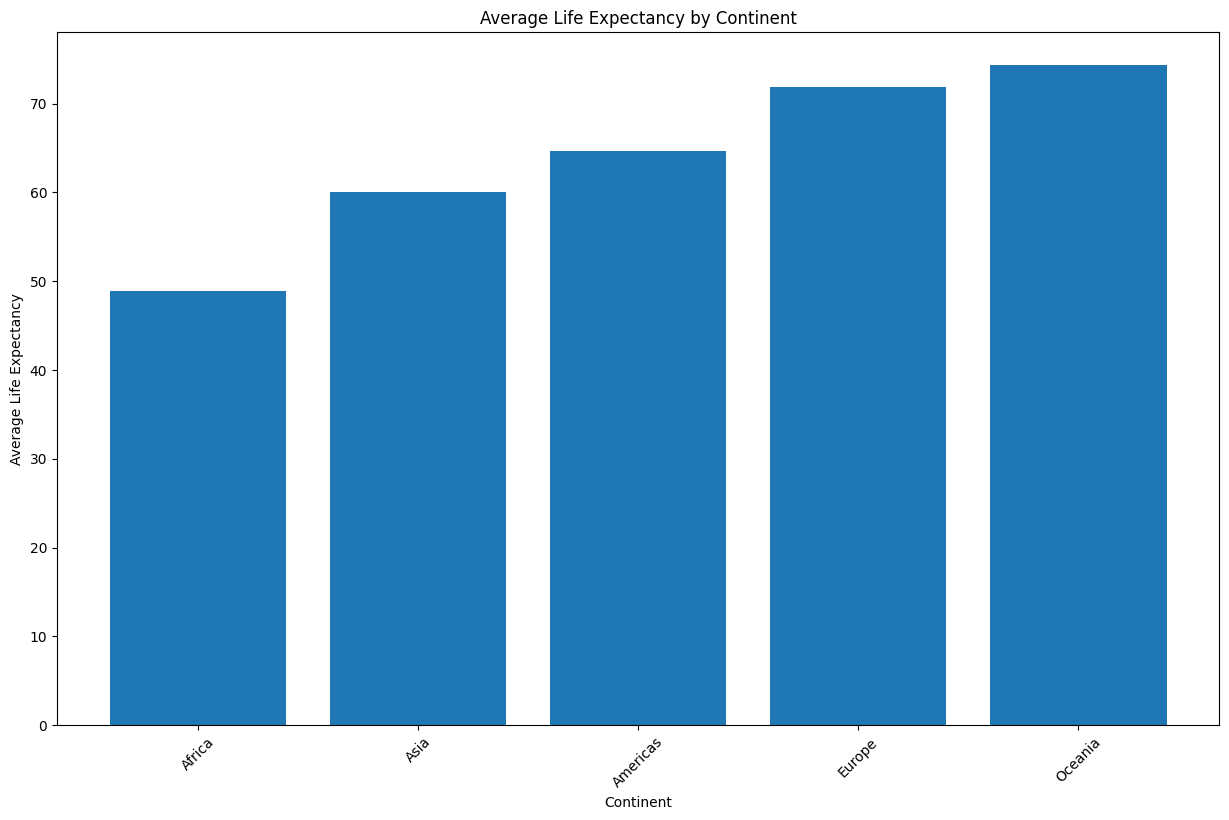

In [37]:
summary = df_clean.groupby("continent")["lifeExp"].mean().sort_values()
plt.figure(figsize=(15,9))
plt.bar(summary.index, summary.values)
plt.xlabel("Continent")
plt.xticks(rotation=45)
plt.ylabel("Average Life Expectancy")
plt.title("Average Life Expectancy by Continent")
plt.show()

In [38]:
latest_year = df_clean["year"].max()
latest_df = df_clean[df_clean["year"] == latest_year].copy()

print("Latest year:", latest_year)
print(latest_df.head())
print(latest_df.shape)

Latest year: 2007
        country  year         pop continent  lifeExp     gdpPercap
11  Afghanistan  2007  31889923.0      Asia   43.828    974.580338
23      Albania  2007   3600523.0    Europe   76.423   5937.029526
35      Algeria  2007  33333216.0    Africa   72.301   6223.367465
47       Angola  2007  12420476.0    Africa   42.731   4797.231267
59    Argentina  2007  40301927.0  Americas   75.320  12779.379640
(142, 6)


In [ ]:
#temporal-time related
#Line chart life expectancy over time for 3 countries India,China,United States

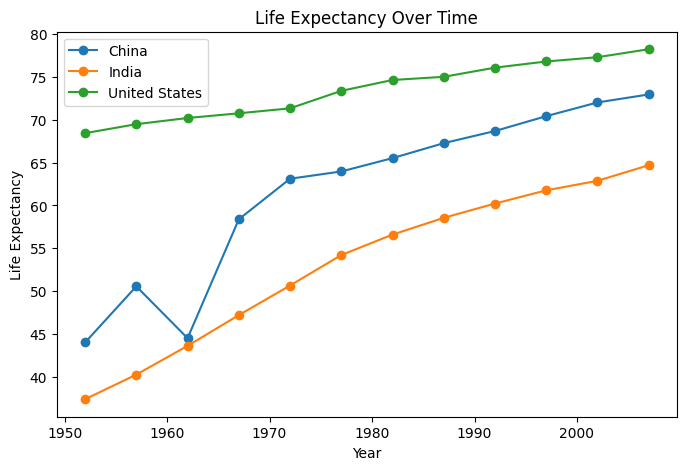

In [41]:
data = df[df["country"].isin(["India","China","United States"])]

plt.figure(figsize=(8,5))

for country in data["country"].unique():
    temp = data[data["country"] == country]
    plt.plot(temp["year"], temp["lifeExp"], marker="o", label=country)

plt.xlabel("Year")
plt.ylabel("Life Expectancy")
plt.title("Life Expectancy Over Time")

plt.legend()

In [ ]:
#Scatterplot-ideal for relationship mapping between two features
#create a scatterplot GDP per capita vs life expectancy

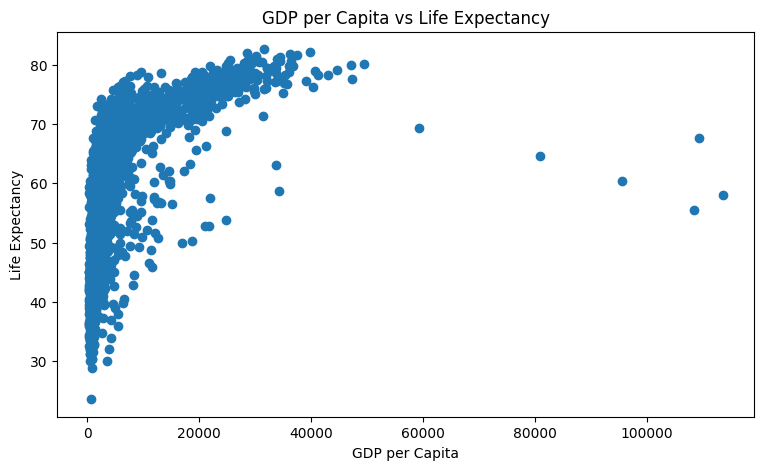

In [47]:
plt.figure(figsize=(9,5))

plt.scatter(df["gdpPercap"], df["lifeExp"])

plt.xlabel("GDP per Capita")
plt.ylabel("Life Expectancy")
plt.title("GDP per Capita vs Life Expectancy")

plt.show()

To write insights:we use 3 main things:

Observations:line of china dips in 1959
Evidence:marker dips in 199 whereas others scale linearly
Meaning:plausible disaster(in ths case famine)
